# 1. Modules and packages: reuse a tested Python file

Learn the difference between a function, module, import package, and installed distribution. You will import a small local utility, inspect where it came from, and compare its result with an independent standard-library calculation. Prerequisite: [List comprehensions](../../../01_Python_Foundations/08_list_comprehensions.ipynb). Allow two hours, including opening the source file and reading its input contract. No new package installation is needed.

## 2. What problem does this solve?

A useful function copied into many notebooks eventually diverges. One copy may reject missing values, another silently drop them, and a third use an old formula. A module puts reusable code in a Python file that different notebooks can import. A package organizes related modules under a shared namespace.

Reuse reduces duplication, but it introduces a new question: which file did the import actually load? Different environments and search paths can contain similarly named modules. Verify the source and interpreter rather than assuming an import's spelling proves its identity.

## 3. Intuition and analogy

A function resembles one tool. A module resembles a labeled toolbox containing related tools. A package resembles a cabinet of toolboxes. An installed distribution is a delivered bundle that can supply one or several importable packages. The label on the delivery box need not match the exact name used to open a toolbox.

For example, pip installs the distribution `scikit-learn`, while Python imports `sklearn`. Do not guess installation names from an import or install an unfamiliar lookalike package merely because a name appears in an error. Consult the project's declared dependencies and the package's official documentation.

## 4. Terminology

A **module** is an importable unit, commonly a `.py` file. A **package** organizes modules under a namespace; a regular package includes `__init__.py`. A **distribution** is the installable artifact managed by pip. The **standard library** ships with Python. A **third-party dependency** is installed separately, while a **local module** belongs to this repository.

`import module` binds a module object; `from module import name` binds a selected object from it. An **alias**, written `as`, supplies another local name. `sys.path` is Python's ordered module search path. `__file__` usually identifies a module's file, and `__name__` identifies how it is loaded. Some special or built-in modules do not have ordinary source files.

## 5. Mathematical foundations

The shared operation will calculate an average:

$$\bar x=\frac{1}{n}\sum_{i=1}^{n}x_i,\qquad n>0.$$

Each $x_i$ is one numerical measurement in the same units, n is the number of measurements, and the output is one scalar with those same units. For a Python sequence of length n, the result is not a new sequence; it is one summary value.

The module's contract additionally requires finite ordinary Python numbers. Boolean flags, missing values, text, and infinities are not accepted measurements. This domain is deliberately narrower than a general scientific library so the implementation remains easy to read and test.

## 6. Hand-calculated example

Invented waiting times two, four, and six minutes sum to twelve minutes across three visits. Dividing by three gives a mean of four minutes. Adding ten minutes to every wait gives 12, 14, and 16, whose mean is 14: the average shifts by the same amount.

An empty list has no arithmetic mean under this definition. A list containing `None` also lacks a recorded numerical value. Our helper rejects these cases rather than deciding how to impute or exclude observations. Missing-data policy belongs to the calling workflow and should be stated explicitly.

## 7. Scratch implementation and the source file

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
def transparent_mean(values):
    if len(values) == 0:
        raise ValueError('A mean requires observations')
    total = 0
    for value in values:
        total += value
    return total / len(values)

example = [2, 4, 6]
assert transparent_mean(example) == 4

This short version exposes addition and division, but has limited validation. The reusable implementation lives in [measurements.py](../../../src/academy/measurements.py). It snapshots the iterable, validates every item, and uses `math.fsum` for summation. Its docstring states the supported input domain and units requirement. Open that file before importing it.

## 8. Import the local package explicitly

The repository uses a `src/` layout. The following setup locates that folder relative to the current notebook or repository directory and adds it to this kernel's search path. It does not alter Windows PATH or install a system-wide package.

In [3]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / 'src' / 'academy' / 'measurements.py').is_file():
    project_root = project_root.parent
source_dir = project_root / 'src'
assert (source_dir / 'academy' / 'measurements.py').is_file(), 'Run from the project or lesson directory'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

from academy import measurements
result = measurements.finite_mean(example)
assert result == 4
assert Path(measurements.__file__).resolve().is_relative_to(source_dir.resolve())
print('Loaded local module:', Path(measurements.__file__).relative_to(project_root))
print('Mean:', result, 'minutes')

Loaded local module: src\academy\measurements.py
Mean: 4.0 minutes


The source-location assertion confirms we loaded this repository's module. A later packaging workflow can install the project into its `.venv` instead of adjusting a notebook search path. This explicit temporary setup keeps the beginner example self-contained with the existing environment.

## 9. Standard-library and distribution comparison

In [4]:
import statistics
from importlib.metadata import version
from academy.measurements import finite_mean as checked_mean
assert statistics.mean(example) == transparent_mean(example) == checked_mean(example)
print('scikit-learn distribution version:', version('scikit-learn'))
import sklearn
assert sklearn.__version__ == version('scikit-learn')

scikit-learn distribution version: 1.9.1


The three mean calculations agree on this valid small input. That does not mean their full contracts are identical: our helper deliberately rejects certain types accepted by other tools. The version lookup reads installed metadata locally; it performs no network request or automatic upgrade.

## 10. Visualization

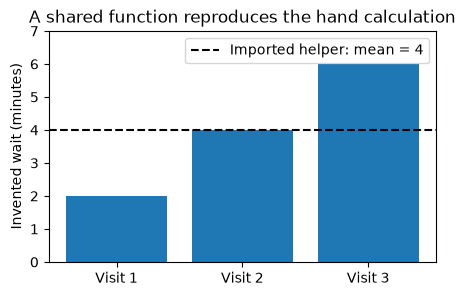

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Visit 1', 'Visit 2', 'Visit 3'], example)
ax.axhline(checked_mean(example), color='black', linestyle='--', label='Imported helper: mean = 4')
ax.set(ylabel='Invented wait (minutes)', title='A shared function reproduces the hand calculation', ylim=(0, 7))
ax.legend()
display(fig)
plt.close(fig)

The average is a summary of three unequal waits. The chart verifies the imported result against an interpretable example, but cannot prove the module works for every possible input. That requires additional contract tests and clearly bounded claims.

## 11. Import caching and input preservation

Python normally reuses an already imported module object within one process. Importing again does not necessarily reread an edited source file. Restart the kernel after changing a module when verifying a notebook from a clean state.

In [6]:
import importlib
again = importlib.import_module('academy.measurements')
assert again is measurements
original = [0, 3, 6]
assert checked_mean(original) == 3
assert original == [0, 3, 6]
assert checked_mean(value for value in [2, 4]) == 3
for invalid in ([], [None], [True], [float('nan')]):
    try:
        checked_mean(invalid)
    except ValueError as error:
        print('Expected contract failure:', error)
    else:
        raise AssertionError('Invalid input accepted')

Expected contract failure: At least one measurement is required
Expected contract failure: Expected ordinary Python numbers, excluding flags
Expected contract failure: Expected ordinary Python numbers, excluding flags
Expected contract failure: Measurements must be finite


The generator case is consumed once into a snapshot. The list case is not changed. The module does not fit a model, access a network service, or read arbitrary data during import. Avoid surprising side effects in reusable module initialization.

## 12. Organization and environment choices

Group related operations by purpose rather than creating one enormous utility file. Use clear names that avoid collisions with standard modules: do not call your own file `math.py`, `statistics.py`, or `numpy.py`. Keep dependencies declared in the project environment. There are no model hyperparameters in this lesson; version and import-path choices describe software configuration.

The `if __name__ == '__main__':` convention lets a Python file run a command-line demonstration only when executed directly, instead of running that demonstration whenever imported. Our utility needs only definitions, so it performs no demonstration at import time.

## 13. Evaluation

Check the loaded source location, expected outputs, invalid-input behavior, and input preservation. Run [test_measurements.py](../../../tests/test_measurements.py) through the project's test command. The tests cover known values, one-pass iterables, malformed input, preservation, and translation/scale properties. Restart-and-run-all also checks that the notebook imports its own prerequisites instead of relying on an earlier session.

## 14. Assumptions and limitations

The temporary source-path setup assumes this repository's documented layout and a kernel started from its root or a module directory. The shared helper is educational, not an all-purpose statistics implementation. Extremely large magnitudes can still exceed floating-point capacity. An import succeeding proves only that Python found loadable code, not that it is trustworthy, mathematically correct, or suitable for the current task.

## 15. Common mistakes and debugging

Do not install packages randomly to fix a spelling or path error. First check the active interpreter, declared dependencies, module name, and `__file__`. Avoid `from module import *`, which hides where names originate. After editing a module, restart rather than assuming old imported function objects update automatically. Do not place secrets or external side effects in code executed at import.

## 16. Comparison with alternatives

Notebook-local functions are convenient while learning one mechanism. Shared modules are useful once several lessons need the same tested contract. Installed packages provide a durable distribution workflow. A script provides a command-line entry point. These formats complement one another; moving code into a file does not remove the need for explanation and tests.

## 17. Exercises

1. **Beginner:** Identify the module and function in `statistics.mean([2,4])`.
2. **Beginner:** Explain why `scikit-learn` and `sklearn` can refer to the same installed software through different naming conventions.
3. **Beginner:** Compute the imported helper's result for `[1,5,9]` by hand.
4. **Intermediate:** Explain why naming your notebook-adjacent file `numpy.py` can break an intended NumPy import.
5. **Intermediate:** Describe how editing a module while keeping its kernel running can leave old behavior in memory.
6. **Challenge:** Design a small contract test set for a shared average function, including valid, empty, malformed, and invariant cases, and explain what it still cannot establish.

## 18. Detailed solutions

1. `statistics` is the module; `mean` is a function accessed through its namespace. The list is the argument.
2. One is a distribution name used by an installer and metadata; the other is its import package name. Their mapping is documented by the project.
3. The sum is 15, the count three, and the mean five.
4. Python's search path can find the local file before the installed package, loading the wrong object under the expected name. Inspect `__file__` and rename the conflicting file.
5. Module caching and separately imported function references may retain old objects. A fresh kernel provides a clean verification boundary.
6. Compare a tiny hand calculation, check rejected inputs, confirm the source stays unchanged, and verify translation and scaling behavior. Passing finite tests does not prove correctness for every magnitude or application.

In [7]:
assert checked_mean([1, 5, 9]) == 5
assert checked_mean([11, 15, 19]) == checked_mean([1, 5, 9]) + 10
assert checked_mean([2, 10, 18]) == 2 * checked_mean([1, 5, 9])
source = [1, 5, 9]
checked_mean(source)
assert source == [1, 5, 9]
failures = 0
for invalid in ([], ['5'], [False], [float('inf')]):
    try:
        checked_mean(invalid)
    except ValueError:
        failures += 1
assert failures == 4
print('Contract examples and invariants passed.')

Contract examples and invariants passed.


## 19. Knowledge check

**What is a module?** An importable unit of Python code. **What is a distribution?** An installable software bundle. **Does another import always reread a file?** No. **Why inspect __file__?** To identify the code actually loaded. **Does a shared helper need tests?** Yes; reuse spreads both correct behavior and defects.

## 20. Interview preparation

**Why organize code into modules?** To reuse a clear contract and reduce divergence across copies. **What does an alias change?** The local binding name, not the imported software's identity. **How diagnose an import error?** Check interpreter, search path, spelling, dependency declaration, and source collision. **Why avoid import-time side effects?** Loading reusable definitions should not unexpectedly change files or trigger external work. **How does packaging support reproducibility?** It makes dependencies and code identity explicit, while execution tests still establish actual behavior.

## 21. Summary and next steps

You loaded a local tested module, verified its identity, and distinguished its contract from a general library. Next study [File handling](../../../01_Python_Foundations/10_file_handling.ipynb), followed by exceptions and classes. See [PROGRESS.md](../../../PROGRESS.md) for exact construction status.